Alunos:        
*   Olavo Ferraz (ofn@cesar.school)
*   Victor Souza (vrss@cesar.school)



In [ ]:
# Baixa e extrai o dataset
!mkdir data/
!curl -L -o data/animais.zip "https://drive.google.com/uc?export=download&id=16Lll0Slg1unWxAb26AzZqI9sPdB_fYpV"
!unzip data/animais.zip -d data

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 11.6M  100 11.6M    0     0  1358k      0  0:00:08  0:00:08 --:--:-- 2843k
Archive:  data/animais.zip
   creating: data/animais/
   creating: data/animais/val/
   creating: data/animais/val/tatu/
  inflating: data/animais/val/tatu/10242.jpg  
  inflating: data/animais/val/tatu/10209.jpg  
  inflating: data/animais/val/tatu/10251.jpg  
  inflating: data/animais/val/tatu/10202.jpg  
  inflating: data/animais/val/tatu/10243.jpg  
  inflating: data/animais/val/tatu/10215.jpg  
  inflating: data/animais/val/tatu/10254.jpg  
  inflating: data/animais/val/tatu/10241.jpg  
  inflating: data/animais/val/tatu/10238.jpg  
  inflating: data/animais/val/tatu/10228.jpg  
  inflating: data/animais/val/tatu/10203.jpg  
  inflating: data/animais/val/tatu/10236.jpg  

In [ ]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Subset
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [ ]:
def train_model(model, trainloader, valloader, criterion, optimizer, device=device, num_epochs=5):
    history = {
        'train_losses': [],
        'val_losses': [],
        'train_accuracies': [],
        'val_accuracies': []
    }

    for epoch in range(num_epochs):
        # Treinamento
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        for i, data in tqdm(enumerate(trainloader, 0), total=len(trainloader)):
            inputs, labels = data
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / len(trainloader)
        train_acc = 100 * correct / total
        history['train_losses'].append(train_loss)
        history['train_accuracies'].append(train_acc)
        print(f'Epoch {epoch+1}, Train Loss: {train_loss:.3f}, Train Accuracy: {train_acc:.2f}%')

        # Validação
        model.eval()
        val_running_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for data in valloader:
                inputs, labels = data
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_running_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_loss = val_running_loss / len(valloader)
        val_acc = 100 * correct / total
        history['val_losses'].append(val_loss)
        history['val_accuracies'].append(val_acc)
        print(f'Epoch {epoch+1}, Val Loss: {val_loss:.3f}, Val Accuracy: {val_acc:.2f}%')

    print('Treinamento concluído')
    return history


def plot_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(history['train_losses'], label='Train')
    ax1.plot(history['val_losses'], label='Validation')
    ax1.set_title('Loss')
    ax1.legend()

    ax2.plot(history['train_accuracies'], label='Train')
    ax2.plot(history['val_accuracies'], label='Validation')
    ax2.set_title('Accuracy')
    ax2.legend()

    plt.show()


def test_model(model, testloader, device=device):
    correct = 0
    total = 0
    with torch.no_grad():
        for data in testloader:
            images, labels = data
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    print(f'Acurácia da rede na base de teste: {100 * correct / total:.2f}%')

In [ ]:
# Carregando os datasets
transform_aug = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

transform_no_aug = transforms.Compose([
    transforms.Resize(230),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# data_dir = 'data/hymenoptera_data'
data_dir = "data/animais"

train_set = datasets.ImageFolder(os.path.join(data_dir, 'train'), transform=transform_aug)
val_set = datasets.ImageFolder(os.path.join(data_dir, 'val'), transform=transform_no_aug)

train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
val_loader = DataLoader(val_set, batch_size=32, shuffle=True)

In [ ]:
model = models.resnet18()

print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
# Substituir a última camada
model.fc = nn.Linear(model.fc.in_features, 2)
model = model.to(device)

print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

100%|██████████| 13/13 [01:36<00:00,  7.45s/it]


Epoch 1, Train Loss: 0.740, Train Accuracy: 48.75%


/usr/local/lib/python3.10/dist-packages/PIL/Image.py:1054: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 1, Val Loss: 0.729, Val Accuracy: 43.44%


100%|██████████| 13/13 [01:35<00:00,  7.31s/it]


...

Epoch 3, Train Loss: 0.675, Train Accuracy: 57.75%
Epoch 3, Val Loss: 0.667, Val Accuracy: 58.20%


100%|██████████| 13/13 [01:39<00:00,  7.63s/it]


Epoch 4, Train Loss: 0.674, Train Accuracy: 58.00%
Epoch 4, Val Loss: 0.655, Val Accuracy: 56.56%


100%|██████████| 13/13 [01:36<00:00,  7.41s/it]


Epoch 5, Train Loss: 0.688, Train Accuracy: 53.75%
Epoch 5, Val Loss: 0.663, Val Accuracy: 63.93%
Treinamento concluído


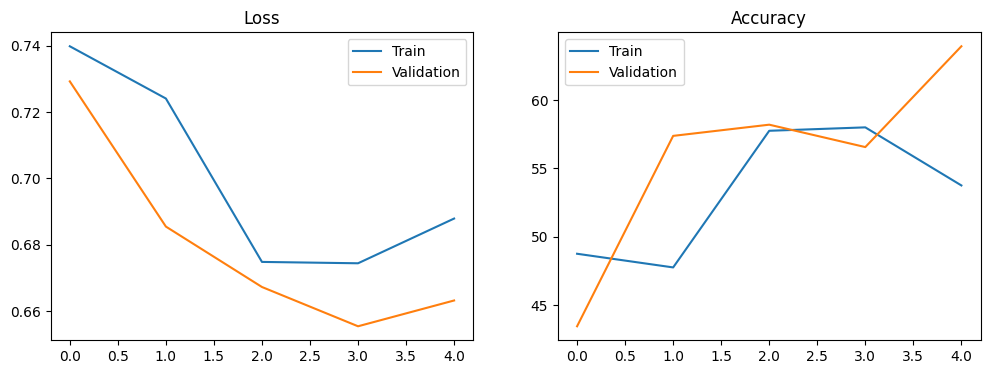

Acurácia da rede na base de teste: 63.93%


In [ ]:
# Treinando a CNN
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

history = train_model(model, train_loader, val_loader, criterion, optimizer, device, num_epochs=5)

plot_history(history)
test_model(model, val_loader)

In [ ]:
# Utilizando pesos pré-treinados
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 140MB/s]


In [ ]:
# Congelar todas as camadas
for param in model.parameters():
    param.requires_grad = False

In [ ]:
# Substituir a última camada
model.fc = nn.Linear(model.fc.in_features, 2)
model = model.to(device)

100%|██████████| 13/13 [00:36<00:00,  2.78s/it]


Epoch 1, Train Loss: 0.643, Train Accuracy: 59.25%
Epoch 1, Val Loss: 0.417, Val Accuracy: 83.61%


100%|██████████| 13/13 [00:36<00:00,  2.78s/it]


Epoch 2, Train Loss: 0.424, Train Accuracy: 82.25%
Epoch 2, Val Loss: 0.288, Val Accuracy: 91.80%


100%|██████████| 13/13 [00:36<00:00,  2.78s/it]


Epoch 3, Train Loss: 0.311, Train Accuracy: 87.00%
Epoch 3, Val Loss: 0.198, Val Accuracy: 91.80%


100%|██████████| 13/13 [00:36<00:00,  2.79s/it]


Epoch 4, Train Loss: 0.296, Train Accuracy: 89.75%
Epoch 4, Val Loss: 0.218, Val Accuracy: 94.26%


100%|██████████| 13/13 [00:35<00:00,  2.75s/it]


Epoch 5, Train Loss: 0.259, Train Accuracy: 91.00%
Epoch 5, Val Loss: 0.134, Val Accuracy: 95.90%
Treinamento concluído


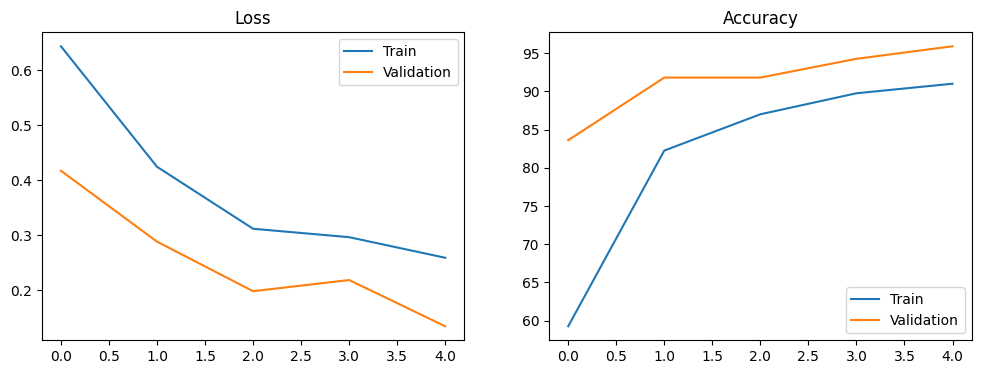

Acurácia da rede na base de teste: 95.90%


In [ ]:
# Treinando a CNN
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

history = train_model(model, train_loader, val_loader, criterion, optimizer, device, num_epochs=5)

plot_history(history)
test_model(model, val_loader)

In [ ]:
def plot_and_predict(model, image, class_names, device=device):
    model.eval()
    image = image.to(device)
    outputs = model(image.unsqueeze(0))
    _, predicted = torch.max(outputs.data, 1)
    probs = F.softmax(outputs, dim=1)[0] * 100
    prob = probs[predicted].item()

    # image between 0 and 1
    image = torch.clamp(image * 0.225 + 0.45, 0, 1)
    title = f'Classe: {class_names[predicted]} ({prob:.2f}%)'
    plt.imshow(image.permute(1, 2, 0).cpu().numpy())
    plt.title(title)
    plt.axis('off')
    plt.show()

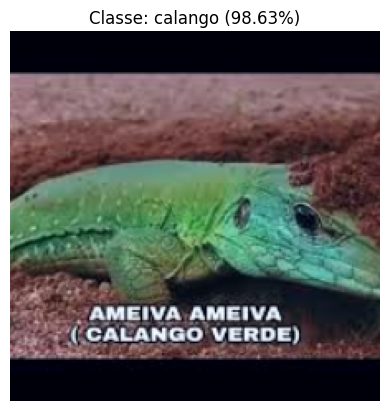

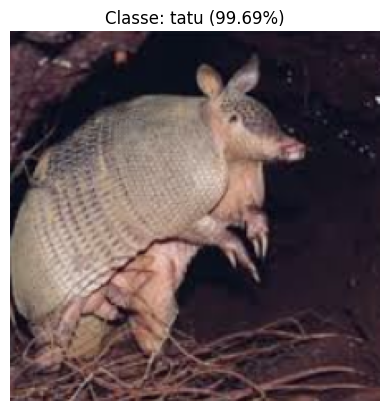

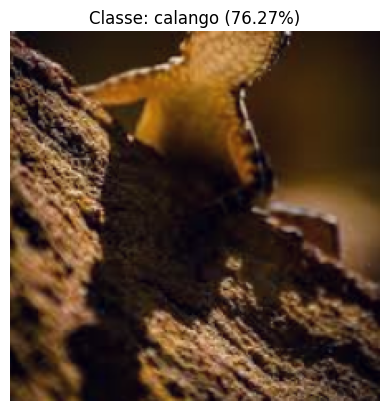

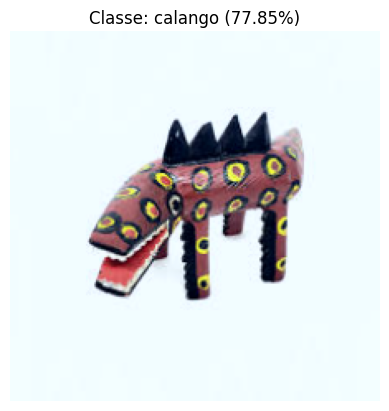

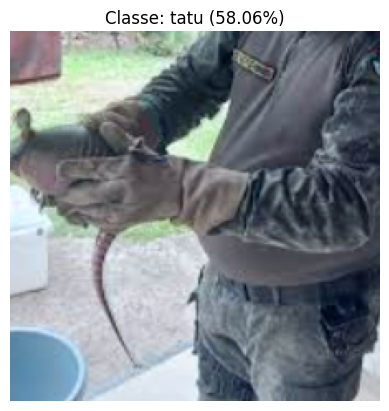

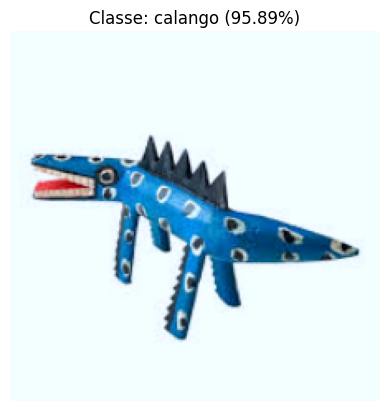

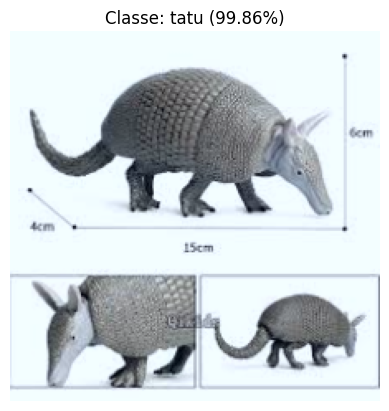

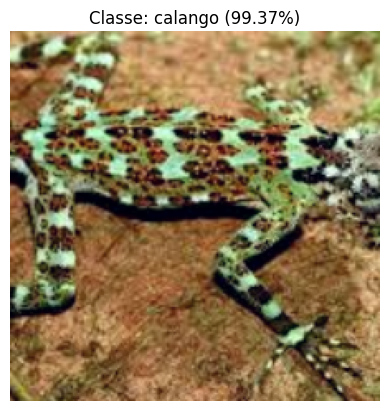

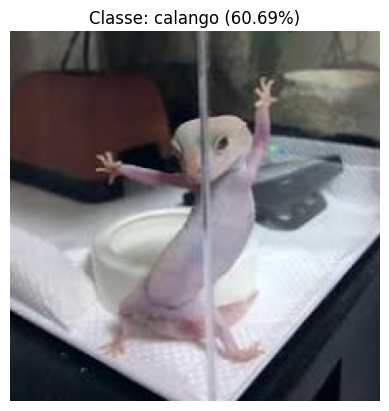

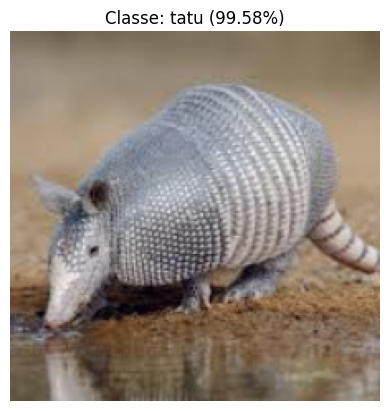

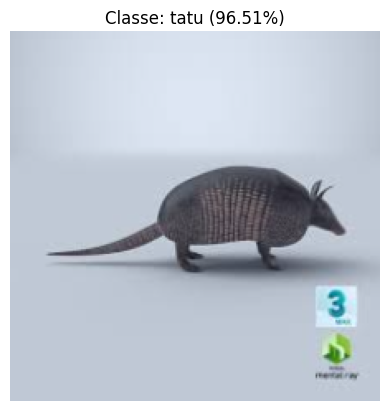

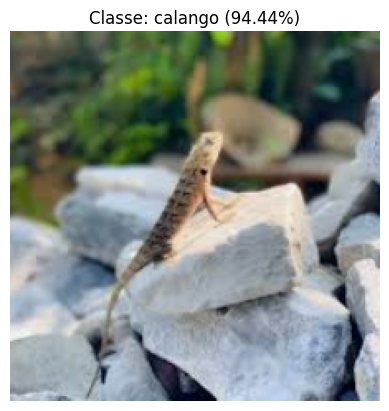

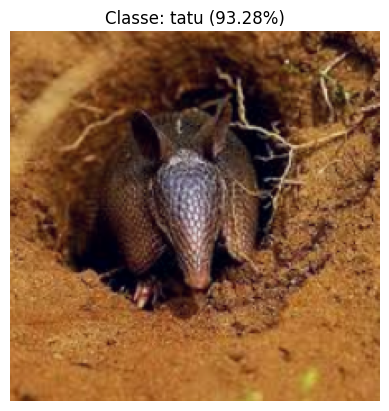

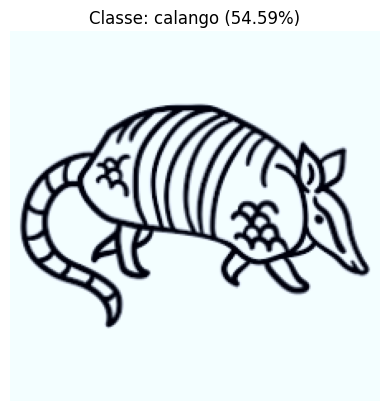

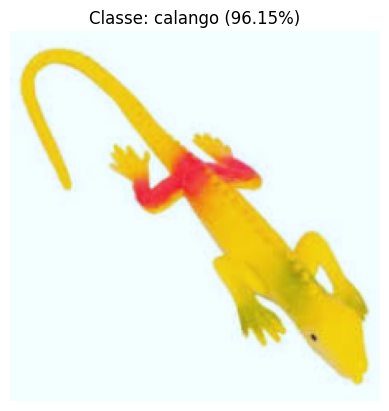

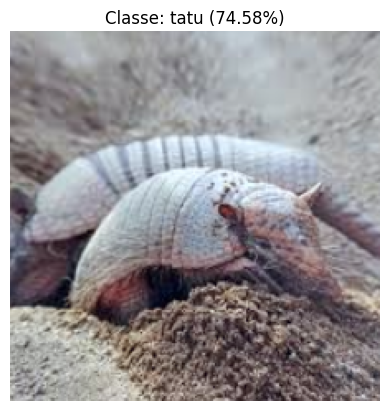

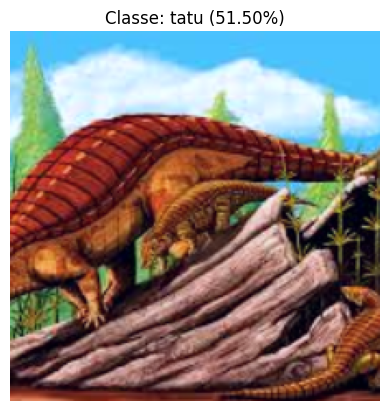

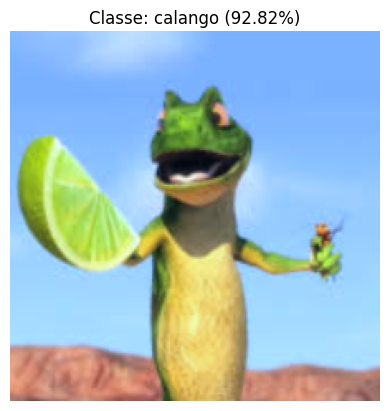

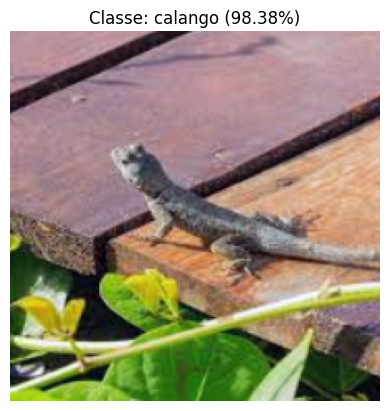

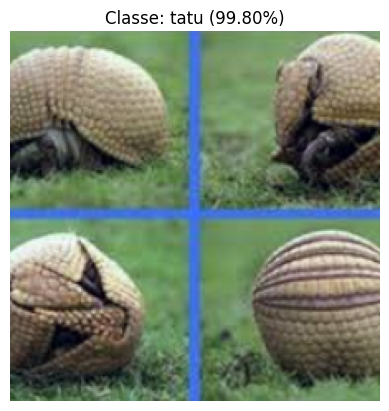

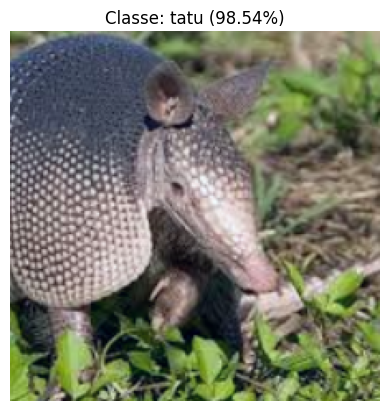

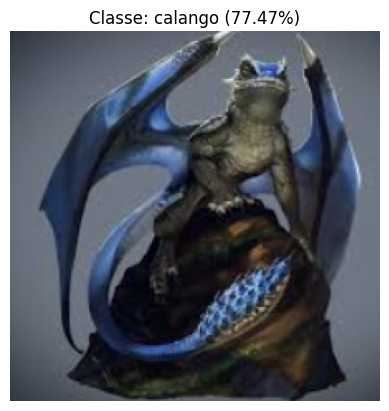

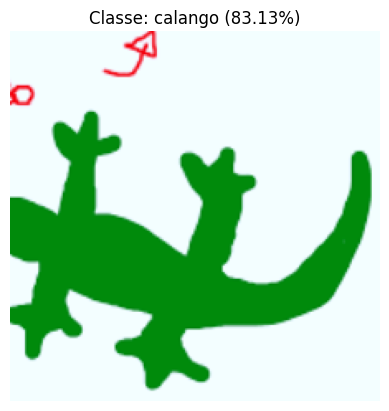

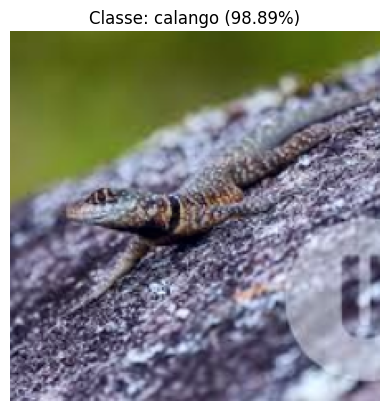

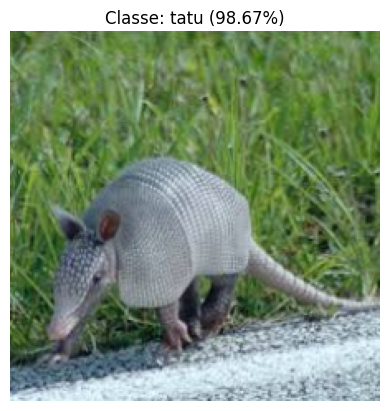

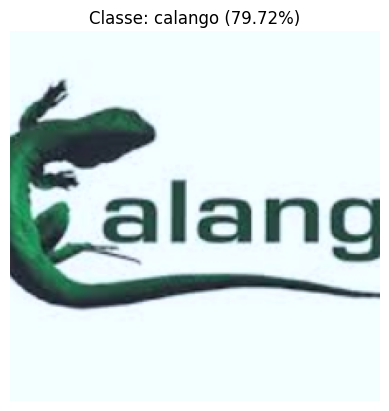

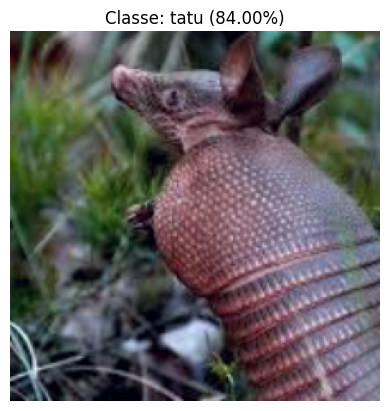

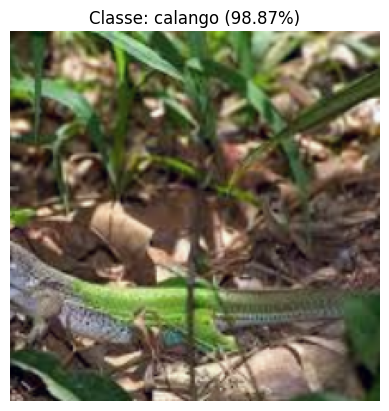

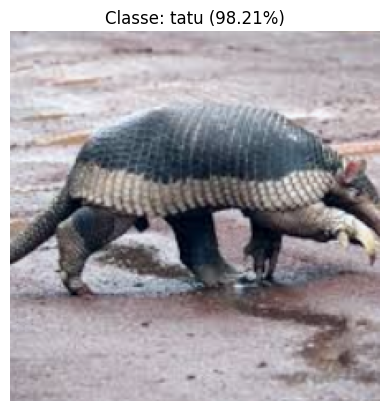

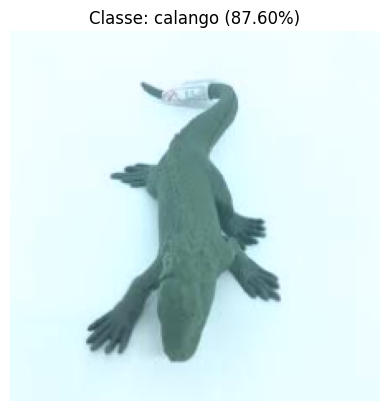

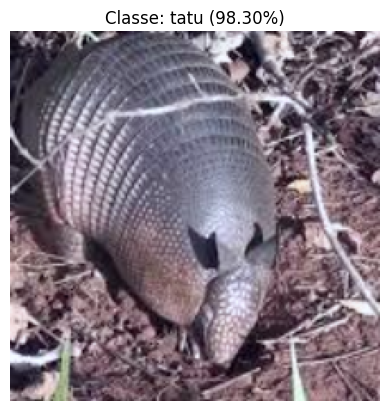

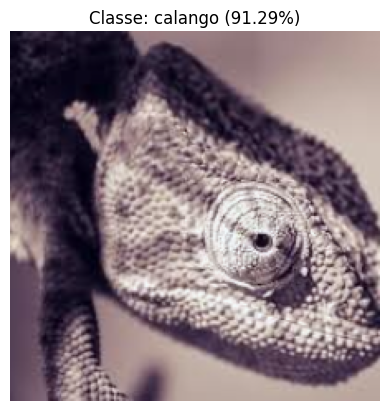

In [ ]:
images, labels = next(iter(val_loader))

for image, label in zip(images, labels):
    plot_and_predict(model, image, val_set.classes)

## Exercícios

### Exercício 1
Treine novamente o modelo, mas sem data augmentation. Compare as curvas de treinamento de ambos os casos e comente.

Treinamento com Data Augmentation:


100%|██████████| 13/13 [00:36<00:00,  2.77s/it]


Epoch 1, Train Loss: 0.668, Train Accuracy: 61.00%
Epoch 1, Val Loss: 0.481, Val Accuracy: 77.87%


100%|██████████| 13/13 [00:35<00:00,  2.71s/it]


Epoch 2, Train Loss: 0.442, Train Accuracy: 81.25%
Epoch 2, Val Loss: 0.275, Val Accuracy: 94.26%


...

Epoch 3, Train Loss: 0.149, Train Accuracy: 95.00%
Epoch 3, Val Loss: 0.144, Val Accuracy: 95.08%


100%|██████████| 13/13 [00:36<00:00,  2.79s/it]


Epoch 4, Train Loss: 0.144, Train Accuracy: 97.00%
Epoch 4, Val Loss: 0.149, Val Accuracy: 94.26%


100%|██████████| 13/13 [00:36<00:00,  2.79s/it]


Epoch 5, Train Loss: 0.149, Train Accuracy: 97.25%
Epoch 5, Val Loss: 0.142, Val Accuracy: 95.08%
Treinamento concluído


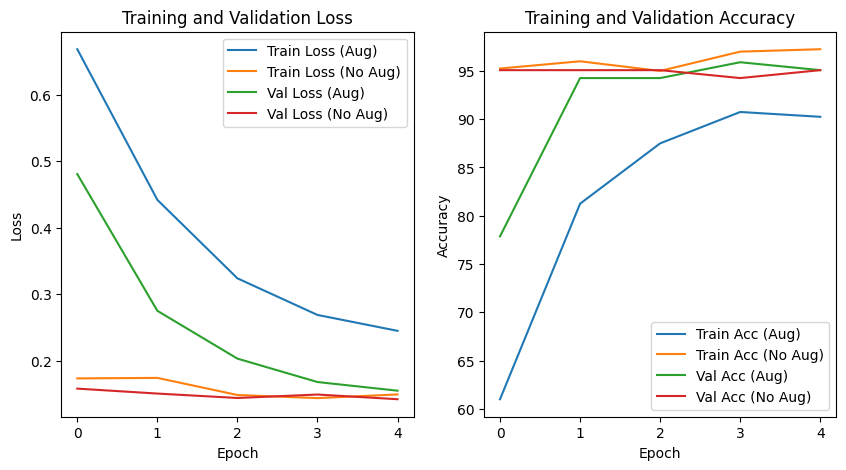

Testando modelo com Data Augmentation:
Acurácia da rede na base de teste: 95.08%
Testando modelo sem Data Augmentation:
Acurácia da rede na base de teste: 95.08%


In [ ]:
transform_aug = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

transform_no_aug = transforms.Compose([
    transforms.Resize(230),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

data_dir = "data/animais"

train_set_aug = datasets.ImageFolder(os.path.join(data_dir, 'train'), transform=transform_aug)
train_set_no_aug = datasets.ImageFolder(os.path.join(data_dir, 'train'), transform=transform_no_aug)
val_set = datasets.ImageFolder(os.path.join(data_dir, 'val'), transform=transform_no_aug)

train_loader_aug = DataLoader(train_set_aug, batch_size=32, shuffle=True)
train_loader_no_aug = DataLoader(train_set_no_aug, batch_size=32, shuffle=True)
val_loader = DataLoader(val_set, batch_size=32, shuffle=True)

model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

for param in model.parameters():
    param.requires_grad = False
model.fc = nn.Linear(model.fc.in_features, 2)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.fc.parameters(), lr=0.001, momentum=0.9)

print("Treinamento com Data Augmentation:")
history_aug = train_model(model, train_loader_aug, val_loader, criterion, optimizer, device, num_epochs=5)

print("Treinamento sem Data Augmentation:")
history_no_aug = train_model(model, train_loader_no_aug, val_loader, criterion, optimizer, device, num_epochs=5)

def plot_comparison(history_aug, history_no_aug):
    plt.figure(figsize=(10, 5))

    # Loss
    plt.subplot(1, 2, 1)
    plt.plot(history_aug['train_losses'], label='Train Loss (Aug)')
    plt.plot(history_no_aug['train_losses'], label='Train Loss (No Aug)')
    plt.plot(history_aug['val_losses'], label='Val Loss (Aug)')
    plt.plot(history_no_aug['val_losses'], label='Val Loss (No Aug)')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()

    # Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history_aug['train_accuracies'], label='Train Acc (Aug)')
    plt.plot(history_no_aug['train_accuracies'], label='Train Acc (No Aug)')
    plt.plot(history_aug['val_accuracies'], label='Val Acc (Aug)')
    plt.plot(history_no_aug['val_accuracies'], label='Val Acc (No Aug)')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.legend()

    plt.show()

plot_comparison(history_aug, history_no_aug)

print("Testando modelo com Data Augmentation:")
test_model(model, val_loader)

print("Testando modelo sem Data Augmentation:")
test_model(model, val_loader)


### Exercício 2
Descongele mais das últimas camadas (à sua escolha), por exemplo `model.layer4[1]`, e treine novamente o modelo.

Camadas descongeladas:
layer4.1.conv1.weight
layer4.1.bn1.weight
layer4.1.bn1.bias
layer4.1.conv2.weight
layer4.1.bn2.weight
layer4.1.bn2.bias
fc.weight
fc.bias
Treinamento com camadas descongeladas:


100%|██████████| 13/13 [00:41<00:00,  3.21s/it]


Epoch 1, Train Loss: 0.639, Train Accuracy: 64.25%
Epoch 1, Val Loss: 0.307, Val Accuracy: 93.44%


100%|██████████| 13/13 [00:42<00:00,  3.25s/it]


Epoch 2, Train Loss: 0.347, Train Accuracy: 89.50%
Epoch 2, Val Loss: 0.189, Val Accuracy: 94.26%


...

Epoch 3, Train Loss: 0.270, Train Accuracy: 90.75%
Epoch 3, Val Loss: 0.135, Val Accuracy: 94.26%


100%|██████████| 13/13 [00:42<00:00,  3.25s/it]


Epoch 4, Train Loss: 0.236, Train Accuracy: 89.75%
Epoch 4, Val Loss: 0.134, Val Accuracy: 96.72%


100%|██████████| 13/13 [00:41<00:00,  3.22s/it]


Epoch 5, Train Loss: 0.201, Train Accuracy: 93.00%
Epoch 5, Val Loss: 0.115, Val Accuracy: 95.90%
Treinamento concluído


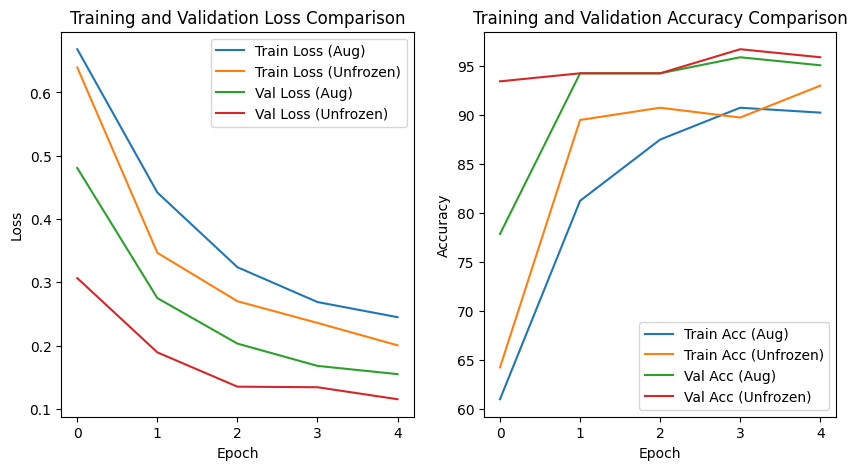

Resultados com camadas descongeladas:
Acurácia da rede na base de teste: 95.90%


In [ ]:
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

for param in model.parameters():
    param.requires_grad = False

for param in model.layer4[1].parameters():
    param.requires_grad = True

model.fc = nn.Linear(model.fc.in_features, 2)

model = model.to(device)

print("Camadas descongeladas:")
for name, param in model.named_parameters():
    if param.requires_grad:
        print(name)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.001,
    momentum=0.9
)

print("Treinamento com camadas descongeladas:")
history_unfrozen = train_model(model, train_loader_aug, val_loader, criterion, optimizer, device, num_epochs=5)

def plot_history_unfrozen(history_aug, history_unfrozen):
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history_aug['train_losses'], label='Train Loss (Aug)')
    plt.plot(history_unfrozen['train_losses'], label='Train Loss (Unfrozen)')
    plt.plot(history_aug['val_losses'], label='Val Loss (Aug)')
    plt.plot(history_unfrozen['val_losses'], label='Val Loss (Unfrozen)')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss Comparison')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history_aug['train_accuracies'], label='Train Acc (Aug)')
    plt.plot(history_unfrozen['train_accuracies'], label='Train Acc (Unfrozen)')
    plt.plot(history_aug['val_accuracies'], label='Val Acc (Aug)')
    plt.plot(history_unfrozen['val_accuracies'], label='Val Acc (Unfrozen)')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Training and Validation Accuracy Comparison')
    plt.legend()

    plt.show()

plot_history_unfrozen(history_aug, history_unfrozen)

print("Resultados com camadas descongeladas:")
test_model(model, val_loader)


### Exercício 3
Escolha outro modelo pré-treinado dos que foram vistos na aula e substitua no modelo. Lembre-se de alterar a última camada de classificação.

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth
100%|██████████| 528M/528M [00:08<00:00, 68.0MB/s]


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

100%|██████████| 13/13 [04:16<00:00, 19.72s/it]


Epoch 1, Train Loss: 0.443, Train Accuracy: 77.50%
Epoch 1, Val Loss: 0.169, Val Accuracy: 92.62%


100%|██████████| 13/13 [04:10<00:00, 19.25s/it]


...

Epoch 3, Train Loss: 0.249, Train Accuracy: 89.00%
Epoch 3, Val Loss: 0.134, Val Accuracy: 93.44%


100%|██████████| 13/13 [04:10<00:00, 19.29s/it]


Epoch 4, Train Loss: 0.218, Train Accuracy: 90.25%
Epoch 4, Val Loss: 0.105, Val Accuracy: 95.08%


100%|██████████| 13/13 [04:10<00:00, 19.24s/it]


Epoch 5, Train Loss: 0.185, Train Accuracy: 92.25%
Epoch 5, Val Loss: 0.142, Val Accuracy: 92.62%
Treinamento concluído


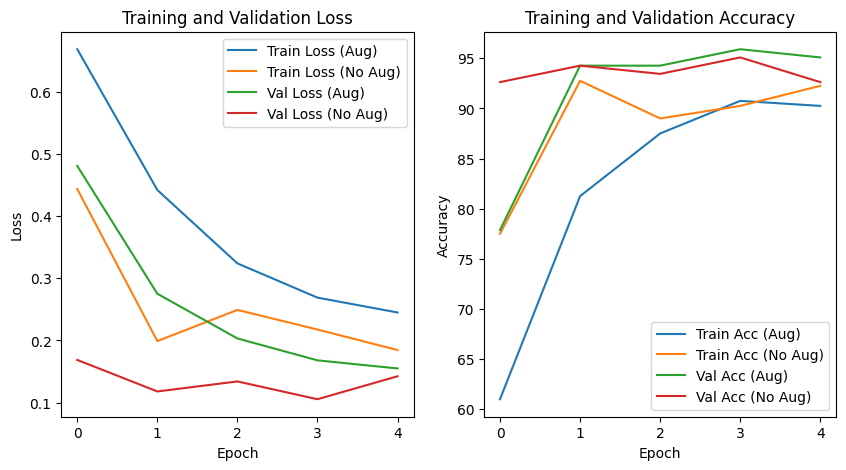

Resultados com VGG16:
Acurácia da rede na base de teste: 92.62%


In [ ]:
# Carregar o modelo VGG16 pré-treinado
model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)

for param in model.features.parameters():
    param.requires_grad = False

num_features = model.classifier[-1].in_features
model.classifier[-1] = nn.Linear(num_features, 2)

model = model.to(device)

print(model)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.classifier[-1].parameters(), lr=0.001, momentum=0.9)

print("Treinamento com VGG16:")
history_vgg16 = train_model(model, train_loader_aug, val_loader, criterion, optimizer, device, num_epochs=5)

plot_comparison(history_aug, history_vgg16)

print("Resultados com VGG16:")
test_model(model, val_loader)
